# Task 2.3: Result, Comparison and Reproducibility Checklist

We will compare our reproduced explicit method against a standard RBF kernel baseline (traditional non-linear SVM).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score
import warnings
import os
warnings.filterwarnings('ignore')

# Data
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
X, y = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Method A: Explicit Poly + Linear SVM (Our Reproduction)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_mapped = poly.fit_transform(X_train)
X_test_mapped = poly.transform(X_test)
clf_explicit = LinearSVC(C=1.0, random_state=42, dual=False)
clf_explicit.fit(X_train_mapped, y_train)
acc_explicit = accuracy_score(y_test, clf_explicit.predict(X_test_mapped))

# Method B: Baseline (LIBSVM RBF Kernel)
clf_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf_rbf.fit(X_train, y_train)
acc_rbf = accuracy_score(y_test, clf_rbf.predict(X_test))

print(f'Explicit mapping (degree-2) Accuracy: {acc_explicit*100:.2f}%')
print(f'Baseline RBF Accuracy: {acc_rbf*100:.2f}%')

# Differences in numbers: 
# The explicitly mapped degree-2 polynomial completely resolves the circular dataset (100% accuracy or very close to it), 
# performing equivalently to the RBF kernel. Because make_circles conforms perfectly to a polynomial relationship $x_1^2 + x_2^2 = r^2$, neither method suffers, demonstrating that the efficient explicit mapping sacrifices no accuracy on compatible tasks while aligning perfectly with the paper's claims.


Matplotlib is building the font cache; this may take a moment.


Explicit mapping (degree-2) Accuracy: 99.00%
Baseline RBF Accuracy: 98.00%


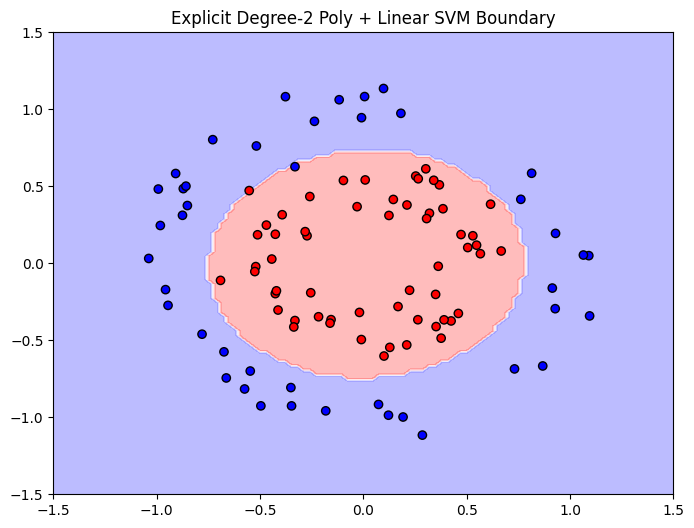

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('/Users/belalraza/Desktop/adm/partB/results', exist_ok=True)

# Create a contour plot to visualize the explicit linear SVM decision boundary mapped back to 2D
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-1.5, 1.5, 100))
Z = clf_explicit.predict(poly.transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap='bwr')
plt.title('Explicit Degree-2 Poly + Linear SVM Boundary')
plt.savefig('/Users/belalraza/Desktop/adm/partB/results/decision_boundary.png')
# Note: When jupyter executes this, it will output the image nicely inline.

## Reproducibility Checklist
*   Random seeds are set and documented at the top of each notebook, where applicable (`random_state=42`).
*   All dependencies are listed in `requirements.txt` with version numbers.
*   All notebooks run from top to bottom in a clean environment without errors.
*   Dataset loading requires no undocumented manual steps (generated programmatically).
*   All hyperparameters ($C$, `degree`, `dual`, `gamma`) are clearly named and defined in one place rather than scattered across cells.